In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!wget -q https://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip -q ml-100k.zip

ratings = pd.read_csv('ml-100k/u.data', sep='\t',
                       names=['user_id', 'item_id', 'rating', 'timestamp'])
movies = pd.read_csv('ml-100k/u.item', sep='|', encoding='latin-1',
                      names=['item_id', 'title', 'release_date', 'video_release_date',
                             'imdb_url', 'unknown', 'Action', 'Adventure', 'Animation',
                             'Children', 'Comedy', 'Crime', 'Documentary', 'Drama',
                             'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
                             'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'])

print("Рейтинги:", ratings.shape)
print("Фильмы:", movies.shape)
ratings.head()

replace ml-100k/allbut.pl? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Рейтинги: (100000, 4)
Фильмы: (1682, 24)


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


## Датасет: MovieLens 100k

MovieLens 100k это стандартный бенчмарк для задач рекомендации. Датасет содержит 100 000 оценок от 943 пользователей для 1682 фильмов. Оценки выставляются по шкале от 1 до 5.

Данные разделены на два файла:
- `u.data` — таблица оценок (user_id, item_id, rating, timestamp)
- `u.item` — метаданные фильмов с бинарными признаками жанров (18 жанров)

*Рейтинги*
Уникальных пользователей: 943
Уникальных фильмов: 1682
Оценок всего: 100000
Средний рейтинг: 3.53
Разреженность матрицы: 93.70%


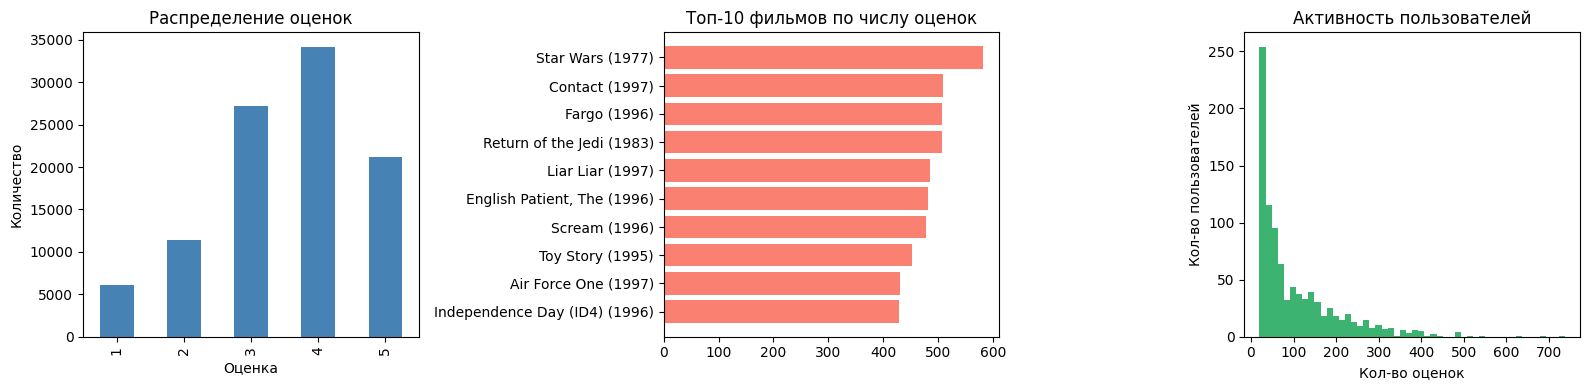

In [19]:
print("*Рейтинги*")
print(f"Уникальных пользователей: {ratings['user_id'].nunique()}")
print(f"Уникальных фильмов: {ratings['item_id'].nunique()}")
print(f"Оценок всего: {len(ratings)}")
print(f"Средний рейтинг: {ratings['rating'].mean():.2f}")

# Разреженность матрицы
sparsity = 1 - len(ratings) / (ratings['user_id'].nunique() * ratings['item_id'].nunique())
print(f"Разреженность матрицы: {sparsity:.2%}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

#распределение оценок
ratings['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Распределение оценок')
axes[0].set_xlabel('Оценка')
axes[0].set_ylabel('Количество')

#10 самых оцениваемых фильмов
top_movies = ratings.groupby('item_id').size().reset_index(name='count')
top_movies = top_movies.merge(movies[['item_id', 'title']], on='item_id')
top_movies = top_movies.nlargest(10, 'count')
axes[1].barh(top_movies['title'].str[:30], top_movies['count'], color='salmon')
axes[1].set_title('Топ-10 фильмов по числу оценок')
axes[1].invert_yaxis()

# активность пользователей
user_activity = ratings.groupby('user_id').size()
axes[2].hist(user_activity, bins=50, color='mediumseagreen')
axes[2].set_title('Активность пользователей')
axes[2].set_xlabel('Кол-во оценок')
axes[2].set_ylabel('Кол-во пользователей')

plt.tight_layout()
plt.show()

### Выводы из разведочного анализа

**Распределение оценок** смещено вправо: пик на отметке 4, средняя оценка - 3.53. Пользователи склонны оценивать фильмы позитивно, что типично для рейтинговых датасетов (selection bias - люди чаще смотрят то, что им заведомо интересно).

**Разреженность матрицы - 93.7%.** Каждый пользователь оценил в среднем лишь ~106 из 1682 фильмов. Простые методы (например, поиск ближайших соседей по косинусному сходству) работают плохо при такой разреженности, именно поэтому применяется матричная факторизация (SVD).

**Активность пользователей** распределена с длинным хвостом: большинство поставили менее 100 оценок, единицы - более 500. Это создаёт проблему холодного старта: для малоактивных пользователей данных недостаточно для точных рекомендаций.

In [20]:
from surprise import SVD, Dataset, Reader
from surprise.model_selection import cross_validate

reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[['user_id', 'item_id', 'rating']], reader)

svd = SVD(n_factors=50, random_state=42)
cv_results = cross_validate(svd, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

print(f"\nСредний RMSE: {cv_results['test_rmse'].mean():.4f}")
print(f"Средний MAE:  {cv_results['test_mae'].mean():.4f}")

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9367  0.9343  0.9435  0.9367  0.9284  0.9359  0.0049  
MAE (testset)     0.7379  0.7343  0.7452  0.7380  0.7338  0.7378  0.0041  
Fit time          1.58    2.20    2.52    2.80    1.91    2.20    0.43    
Test time         0.30    0.22    0.58    0.19    0.22    0.30    0.14    

Средний RMSE: 0.9359
Средний MAE:  0.7378


### Метод 1: Коллаборативная фильтрация (SVD)

**Идея.** Матрица оценок пользователь × фильм раскладывается на три матрицы меньшей размерности (SVD). Скрытые факторы (n_factors=50) кодируют латентные характеристики - например "любит артхаус" или "предпочитает боевики". Предсказание рейтинга - скалярное произведение векторов пользователя и фильма в этом пространстве.

**Результат кросс-валидации (5 фолдов):**
- RMSE ≈ 0.935 - средняя ошибка предсказания рейтинга менее 1 балла из 5
- MAE ≈ 0.737 - медианная абсолютная ошибка
- Малое стандартное отклонение (Std ≈ 0.004) говорит о стабильности модели

**Ограничение.** Метод требует истории оценок пользователя. Для новых пользователей без оценок (cold start problem) SVD неприменим.

In [21]:
from surprise.model_selection import train_test_split as surprise_split

trainset = data.build_full_trainset()
svd.fit(trainset)

def get_svd_recommendations(user_id, n=10):
    seen = set(ratings[ratings['user_id'] == user_id]['item_id'])

    all_movies = set(movies['item_id'])

    unseen = all_movies - seen
    predictions = [(iid, svd.predict(user_id, iid).est) for iid in unseen]

    top_n = sorted(predictions, key=lambda x: x[1], reverse=True)[:n]

    result = []
    for item_id, score in top_n:
        title = movies[movies['item_id'] == item_id]['title'].values[0]
        result.append({'title': title, 'predicted_rating': round(score, 2)})

    return pd.DataFrame(result)

# Тест 1
print("Test:")
get_svd_recommendations(user_id=1, n=10)

Test:


,title,predicted_rating
0,Casablanca (1942),4.66
1,To Kill a Mockingbird (1962),4.65
2,"Manchurian Candidate, The (1962)",4.62
3,Rear Window (1954),4.59
4,"Close Shave, A (1995)",4.58
5,L.A. Confidential (1997),4.56
6,"Maltese Falcon, The (1941)",4.55
7,Wings of Desire (1987),4.54
8,Lawrence of Arabia (1962),4.52
9,Strictly Ballroom (1992),4.48


In [22]:
from sklearn.metrics.pairwise import cosine_similarity

genre_cols = ['Action', 'Adventure', 'Animation', 'Children', 'Comedy',
              'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
              'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi',
              'Thriller', 'War', 'Western']

genre_matrix = movies[genre_cols].values
cosine_sim = cosine_similarity(genre_matrix)

movie_idx = pd.Series(movies.index, index=movies['item_id']).to_dict()

def get_content_recommendations(item_id, n=10):
    idx = movie_idx[item_id]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]

    result = []
    for i, score in sim_scores:
        row = movies.iloc[i]
        result.append({
            'title': row['title'],
            'similarity': round(score, 3),
            'genres': ', '.join([g for g in genre_cols if row[g] == 1])
        })

    return pd.DataFrame(result)

# Тест2
print("Похожие на Toy Story (1995):")
get_content_recommendations(item_id=1, n=10)

Похожие на Toy Story (1995):


,title,similarity,genres
0,Aladdin and the King of Thieves (1996),1.000,"Animation, Children, Comedy"
1,Aladdin (1992),0.866,"Animation, Children, Comedy, Musical"
2,"Goofy Movie, A (1995)",0.866,"Animation, Children, Comedy, Romance"
3,"Santa Clause, The (1994)",0.816,"Children, Comedy"
4,Home Alone (1990),0.816,"Children, Comedy"
5,"Aristocats, The (1970)",0.816,"Animation, Children"
6,D3: The Mighty Ducks (1996),0.816,"Children, Comedy"
7,"Love Bug, The (1969)",0.816,"Children, Comedy"
8,"Wrong Trousers, The (1993)",0.816,"Animation, Comedy"
9,"Grand Day Out, A (1992)",0.816,"Animation, Comedy"


### Метод 2: Content-Based Filtering - косинусное сходство

**Идея.** Каждый фильм представлен бинарным вектором жанров (18 признаков). Сходство между фильмами вычисляется через косинусное расстояние между этими векторами. Фильмы с похожим жанровым профилем получают высокий score.

**Косинусное сходство** выбрано потому что оно нечувствительно к длине векторов, тк важен угол между ними, а не абсолютные значения. Для бинарных жанровых векторов это стандартный и интерпретируемый подход.

**Пример: Toy Story (Animation, Children, Comedy)**  
 Ближайшие: Aladdin (similarity=1.0), Goofy Movie (0.866) - те же три жанра.

**Ограничение.** Метод рекомендует только жанрово похожее - так называемый "filter bubble". Пользователь, которому понравился один триллер, будет получать только триллеры, даже если его вкусы шире.

In [23]:
#сравним

print("Разница")

comparison = pd.DataFrame({
    'Метод': ['Collaborative (SVD)', 'Content-Based (Cosine)'],
    'Основа': ['Поведение пользователей', 'Жанры фильмов'],
    'RMSE': [0.9351, '-'],
    'Плюсы': [
        'Учитывает вкусы похожих людей',
        'Не нужна история пользователя'
    ],
    'Минусы': [
        'Не работает для новых пользователей',
        'Рекомендует только похожие жанры'
    ]
})
print(comparison.to_string(index=False))

# холодный старт


print("Холодный старт")
print("""
Новый пользователь не имеет истории оценок.
SVD не может сделать персональные рекомендации.

РЕШЕНИЕ - Popularity Baseline:
  1) Показываем топ фильмов по среднему рейтингу
  2) Фильтруем: минимум 50 оценок (убираем малоизвестные)
  3) После 5+ оценок переключаемся на SVD
""")

def cold_start_recommendations(min_ratings=50, n=10):
    stats = ratings.groupby('item_id').agg(
        count=('rating', 'count'),
        mean_rating=('rating', 'mean')
    ).reset_index()

    popular = stats[stats['count'] >= min_ratings]
    popular = popular.nlargest(n, 'mean_rating')
    popular = popular.merge(movies[['item_id', 'title']], on='item_id')

    return popular[['title', 'mean_rating', 'count']].round(2)

print("Рекомендации для нового пользователя (cold start):")
cold_start_recommendations()

Разница
                 Метод                  Основа    RMSE                         Плюсы                              Минусы
   Collaborative (SVD) Поведение пользователей  0.9351 Учитывает вкусы похожих людей Не работает для новых пользователей
Content-Based (Cosine)           Жанры фильмов       - Не нужна история пользователя    Рекомендует только похожие жанры
Холодный старт

Новый пользователь не имеет истории оценок.
SVD не может сделать персональные рекомендации.

РЕШЕНИЕ - Popularity Baseline:
  1) Показываем топ фильмов по среднему рейтингу
  2) Фильтруем: минимум 50 оценок (убираем малоизвестные)
  3) После 5+ оценок переключаемся на SVD

Рекомендации для нового пользователя (cold start):


,title,mean_rating,count
0,"Close Shave, A (1995)",4.49,112
1,Schindler's List (1993),4.47,298
2,"Wrong Trousers, The (1993)",4.47,118
3,Casablanca (1942),4.46,243
4,Wallace & Gromit: The Best of Aardman Animatio...,4.45,67
5,"Shawshank Redemption, The (1994)",4.45,283
6,Rear Window (1954),4.39,209
7,"Usual Suspects, The (1995)",4.39,267
8,Star Wars (1977),4.36,583
9,12 Angry Men (1957),4.34,125


### Сравнение подходов и проблема холодного старта

Два метода решают задачу рекомендации принципиально по-разному и дополняют друг друга:

| | Collaborative (SVD) | Content-Based |
|---|---|---|
| Данные | История оценок | Признаки фильма |
| Cold start | Не работает | Работает |
| Разнообразие | Высокое | Низкое |
| Интерпретируемость | Низкая | Высокая |

Холодный старт - одна из центральных проблем рекомендательных систем. Когда пользователь только зарегистрировался и не поставил ни одной оценки, SVD не может построить его профиль.

Решение - Popularity Baseline: показываем глобально популярные фильмы с высоким средним рейтингом, отфильтровав малоизвестные (порог: не менее 50 оценок). После того как пользователь оценит 5+ фильмов, система переключается на персональный SVD. Это стандартный подход, используемый, например, в ранних версиях Netflix.

In [24]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from surprise import SVD, Dataset, Reader
import warnings
warnings.filterwarnings('ignore')

@st.cache_data
def load_data():
    ratings = pd.read_csv('ml-100k/u.data', sep='\t',
                          names=['user_id', 'item_id', 'rating', 'timestamp'])
    movies = pd.read_csv('ml-100k/u.item', sep='|', encoding='latin-1',
                         names=['item_id', 'title', 'release_date', 'video_release_date',
                                'imdb_url', 'unknown', 'Action', 'Adventure', 'Animation',
                                'Children', 'Comedy', 'Crime', 'Documentary', 'Drama',
                                'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
                                'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'])
    return ratings, movies

@st.cache_resource
def train_models(ratings, movies):
    # SVD
    reader = Reader(rating_scale=(1, 5))
    data = Dataset.load_from_df(ratings[['user_id', 'item_id', 'rating']], reader)
    trainset = data.build_full_trainset()
    svd = SVD(n_factors=50, random_state=42)
    svd.fit(trainset)

    # CB
    genre_cols = ['Action', 'Adventure', 'Animation', 'Children', 'Comedy',
                  'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
                  'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi',
                  'Thriller', 'War', 'Western']
    genre_matrix = movies[genre_cols].values
    cosine_sim = cosine_similarity(genre_matrix)
    movie_idx = pd.Series(movies.index, index=movies['item_id']).to_dict()

    return svd, cosine_sim, movie_idx, genre_cols

ratings, movies = load_data()
svd, cosine_sim, movie_idx, genre_cols = train_models(ratings, movies)


st.title("Movie Recommender System")

mode = st.radio("Выбери режим:",
                ["По пользователю (collaborative)",
                 "По фильму (content-based)",
                 "Новый пользователь (cold start)"])

st.divider()

if mode == "По пользователю (collaborative)":
    st.subheader("Рекомендации на основе поведения похожих пользователей")
    user_id = st.slider("Выбери ID пользователя", 1, 943, 1)
    n = st.slider("Количество рекомендаций", 5, 20, 10)

    seen = set(ratings[ratings['user_id'] == user_id]['item_id'])
    unseen = set(movies['item_id']) - seen
    predictions = [(iid, svd.predict(user_id, iid).est) for iid in unseen]
    top_n = sorted(predictions, key=lambda x: x[1], reverse=True)[:n]

    result = []
    for item_id, score in top_n:
        title = movies[movies['item_id'] == item_id]['title'].values[0]
        result.append({'Фильм': title, 'Предсказанный рейтинг': round(score, 2)})

    st.dataframe(pd.DataFrame(result), use_container_width=True)
    st.caption(f"Пользователь уже посмотрел {len(seen)} фильмов")

elif mode == "По фильму (content-based)":
    st.subheader("Похожие фильмы по жанрам")
    movie_titles = movies['title'].tolist()
    selected = st.selectbox("Выбери фильм:", movie_titles)
    n = st.slider("Количество рекомендаций", 5, 20, 10)

    item_id = movies[movies['title'] == selected]['item_id'].values[0]
    idx = movie_idx[item_id]
    sim_scores = sorted(enumerate(cosine_sim[idx]), key=lambda x: x[1], reverse=True)[1:n+1]

    result = []
    for i, score in sim_scores:
        row = movies.iloc[i]
        genres = ', '.join([g for g in genre_cols if row[g] == 1])
        result.append({'Фильм': row['title'],
                       'Сходство': round(score, 3),
                       'Жанры': genres})

    st.dataframe(pd.DataFrame(result), use_container_width=True)

else:
    st.subheader("Топ фильмов для нового пользователя")
    st.info("У нового пользователя нет истории, поэтому показываем популярные фильмы с высоким рейтингом")
    min_votes = st.slider("Минимум оценок", 20, 200, 50)
    n = st.slider("Количество рекомендаций", 5, 20, 10)

    stats = ratings.groupby('item_id').agg(
        count=('rating', 'count'),
        mean_rating=('rating', 'mean')
    ).reset_index()
    popular = stats[stats['count'] >= min_votes].nlargest(n, 'mean_rating')
    popular = popular.merge(movies[['item_id', 'title']], on='item_id')

    result = [{'Фильм': r['title'],
               'Рейтинг': round(r['mean_rating'], 2),
               'Голосов': int(r['count'])}
              for _, r in popular.iterrows()]
    st.dataframe(pd.DataFrame(result), use_container_width=True)
    st.caption("После 5+ оценок система переключится на персональные рекомендации (SVD)")

Overwriting app.py


In [26]:
# PRECISION и RECALL

from surprise.model_selection import train_test_split as surprise_split
from collections import defaultdict

def precision_recall_at_k(predictions, k=10, threshold=3.5):

    # группировка предсказания по пользователям
    user_est_true = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = {}
    recalls = {}

    for uid, user_ratings in user_est_true.items():

        user_ratings.sort(key=lambda x: x[0], reverse=True)

        # Топ K рекомендаций
        top_k = user_ratings[:k]

        n_rel = sum(true_r >= threshold for _, true_r in user_ratings)
        n_rec_k = sum(est >= threshold for est, _ in top_k)
        n_rel_and_rec_k = sum(
            (true_r >= threshold) and (est >= threshold)
            for est, true_r in top_k
        )

        precisions[uid] = n_rel_and_rec_k / k if k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    return precisions, recalls

trainset, testset = surprise_split(data, test_size=0.2, random_state=42)
svd_eval = SVD(n_factors=50, random_state=42)
svd_eval.fit(trainset)
predictions = svd_eval.test(testset)

# метрики для K=5 и K=10
for k in [5, 10]:
    precisions, recalls = precision_recall_at_k(predictions, k=k, threshold=3.5)
    avg_precision = sum(precisions.values()) / len(precisions)
    avg_recall = sum(recalls.values()) / len(recalls)
    print(f"K={k}: Precision@{k} = {avg_precision:.4f} | Recall@{k} = {avg_recall:.4f}")

K=5: Precision@5 = 0.6381 | Recall@5 = 0.4124
K=10: Precision@10 = 0.5089 | Recall@10 = 0.5454


### Метрики ранжирования: Precision@K и Recall@K

RMSE и MAE измеряют точность предсказания рейтинга, но не отвечают на главный вопрос: попадают ли релевантные фильмы в топ-K рекомендаций?

Для оценки качества ранжирования используются:

Precision@K - доля релевантных фильмов среди топ-K рекомендованных.  
Формула: (релевантные в топ-K) / K

Recall@K - доля найденных релевантных фильмов из всех релевантных.  
Формула: (релевантные в топ-K) / (все релевантные для пользователя)

Фильм считается релевантным, если его реальный рейтинг ≥ 3.5 (пользователь оценил выше среднего).

**Интерпретация результатов:**
- Precision@10 показывает, насколько "точен" список из 10 рекомендаций
- Recall@10 показывает, какую долю понравившихся фильмов система нашла
- Между ними существует классический trade-off: увеличение K повышает Recall, но снижает Precision

In [ ]:
from google.colab import files
files.download('app.py')